In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/raw_datasets/web_traffic.csv'
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df.head())

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


# **Data Dictionary**

| Column Name                | Data Type | Description |
|---------------------------|----------|-------------|
| date                      | date     | Ngày ghi nhận lưu lượng truy cập |
| sessions                  | int      | Tổng số phiên truy cập trong ngày |
| unique_visitors           | int      | Số lượng khách truy cập duy nhất |
| page_views                | int      | Tổng số lượt xem trang |
| bounce_rate               | float    | Tỷ lệ phiên chỉ xem một trang rồi thoát |
| avg_session_duration_sec  | float    | Thời gian trung bình mỗi phiên (tính bằng giây) |
| traffic_source            | str      | Kênh nguồn dẫn traffic về website (ví dụ: Organic, Paid, Social, Direct) |

# **Dataset Overview & Data Quality Checks**

### **1. Dataset Overview**

In [4]:
print('--- Dataset Info ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

print('\n--- Statistical Summary ---')
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   object 
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 199.8+ KB

--- Missing Values ---
date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Statistica

,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,25041.768072,19031.404436,108615.224535,0.004487,210.283242
std,9422.609335,7237.953062,44472.055524,0.000753,63.771711
min,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,50947.000000,40430.000000,275560.000000,0.005800,319.900000


In [6]:
df_copy = df.copy()
# Chuyển đổi cột date sang kiểu datetime
df_copy['date'] = pd.to_datetime(df_copy['date'])

# Kiểm tra khoảng thời gian
min_date = df_copy['date'].min()
max_date = df_copy['date'].max()
total_days = (max_date - min_date).days + 1

print(f'Ngày bắt đầu: {min_date.date()}')
print(f'Ngày kết thúc: {max_date.date()}')
print(f'Tổng số ngày trong dữ liệu: {len(df_copy["date"].unique())}')
print(f'Khoảng cách thời gian thực tế: {total_days} ngày')

# Kiểm tra xem có ngày nào bị thiếu không
if len(df_copy['date'].unique()) == total_days:
    print('\n=> Dữ liệu liên tục, không có ngày bị thiếu.')
else:
    print('\n=> Cảnh báo: Có ngày bị thiếu trong chuỗi thời gian.')

Ngày bắt đầu: 2013-01-01
Ngày kết thúc: 2022-12-31
Tổng số ngày trong dữ liệu: 3652
Khoảng cách thời gian thực tế: 3652 ngày

=> Dữ liệu liên tục, không có ngày bị thiếu.


**Nhận xét về bộ dữ liệu:**

1. **Quy mô và Cấu trúc:**
    * Bộ dữ liệu có **3,652 dòng** và **7 cột**, tương ứng với khoảng 10 năm dữ liệu (nếu ghi nhận theo ngày).
    * Các cột bao gồm thông tin quan trọng về traffic: `date`, `sessions`, `unique_visitors`, `page_views`, `bounce_rate`, `avg_session_duration_sec`, và `traffic_source`.

2. **Chất lượng dữ liệu (Data Quality):**
    * **Giá trị thiếu (Missing Values):** Không có giá trị thiếu (null) ở bất kỳ cột nào. Điều này giúp việc phân tích không bị gián đoạn.
    * **Dữ liệu trùng lặp (Duplicates):** Không có dòng dữ liệu nào bị lặp lại, đảm bảo tính duy nhất của từng bản ghi.
    * **Kiểu dữ liệu:** Cột `date` hiện đang ở kiểu `object` (string). Để phân tích chuỗi thời gian, cần chuyển đổi cột này sang định dạng `datetime`.

3. **Thống kê mô tả (Statistical Insights):**
    * **Sessions & Visitors:** Số lượng phiên truy cập trung bình khoảng 10,000 mỗi ngày. Cần kiểm tra mối quan hệ giữa `sessions` và `unique_visitors` để xem độ trung thành của khách hàng.
    * **Bounce Rate:** Tỷ lệ thoát dao động ổn định (cần quan sát thêm biểu đồ để phát hiện điểm bất thường).
    * **Avg Session Duration:** Thời gian truy cập trung bình có sự biến động, đây là chỉ số quan trọng để đánh giá chất lượng nội dung.

**Đề xuất các bước tiếp theo (Next Steps)**

**1. Đối với Dữ liệu số (Numerical Data)**
- **Xử lý Outliers:** Kiểm tra các giá trị bất thường ở `sessions`, `page_views`, `bounce_rate` để quyết định giữ lại hay xử lý (Log Transformation/Winsorization).
- **Phân tích Tương quan:** Vẽ Heatmap để xem mối quan hệ giữa các chỉ số. Ví dụ: `sessions` tăng thì `page_views` có tăng tương ứng không?
- **Phân tích Chuỗi thời gian:** Quan sát xu hướng (Trend) và tính mùa vụ (Seasonality) theo ngày, tháng, năm.

**2. Đối với Dữ liệu phân loại (Categorical Data)**
- **Phân tích Nguồn lưu lượng (Traffic Source):** Thống kê tỷ lệ phần trăm đóng góp của từng nguồn (Organic, Paid, Social, Direct).
- **So sánh hiệu quả theo nguồn:** So sánh `bounce_rate` và `avg_session_duration_sec` giữa các nguồn để tìm ra kênh mang lại traffic chất lượng nhất.

**3. Feature Engineering (Nếu cần)**
- Tạo thêm các biến như `is_weekend`, `is_holiday` hoặc các biến trễ (lag) để hỗ trợ dự báo.

## **2. Data Quality Check**

### **NUMERICAL DATA**

**Outlier Detection**

Chúng ta sẽ sử dụng phương pháp **Interquartile Range (IQR)** để xác định các giá trị ngoại lệ và trực quan hóa bằng **Boxplot**.

--- Outlier Detection (IQR) ---
sessions: 0 outliers
unique_visitors: 0 outliers
page_views: 18 outliers
bounce_rate: 0 outliers
avg_session_duration_sec: 0 outliers


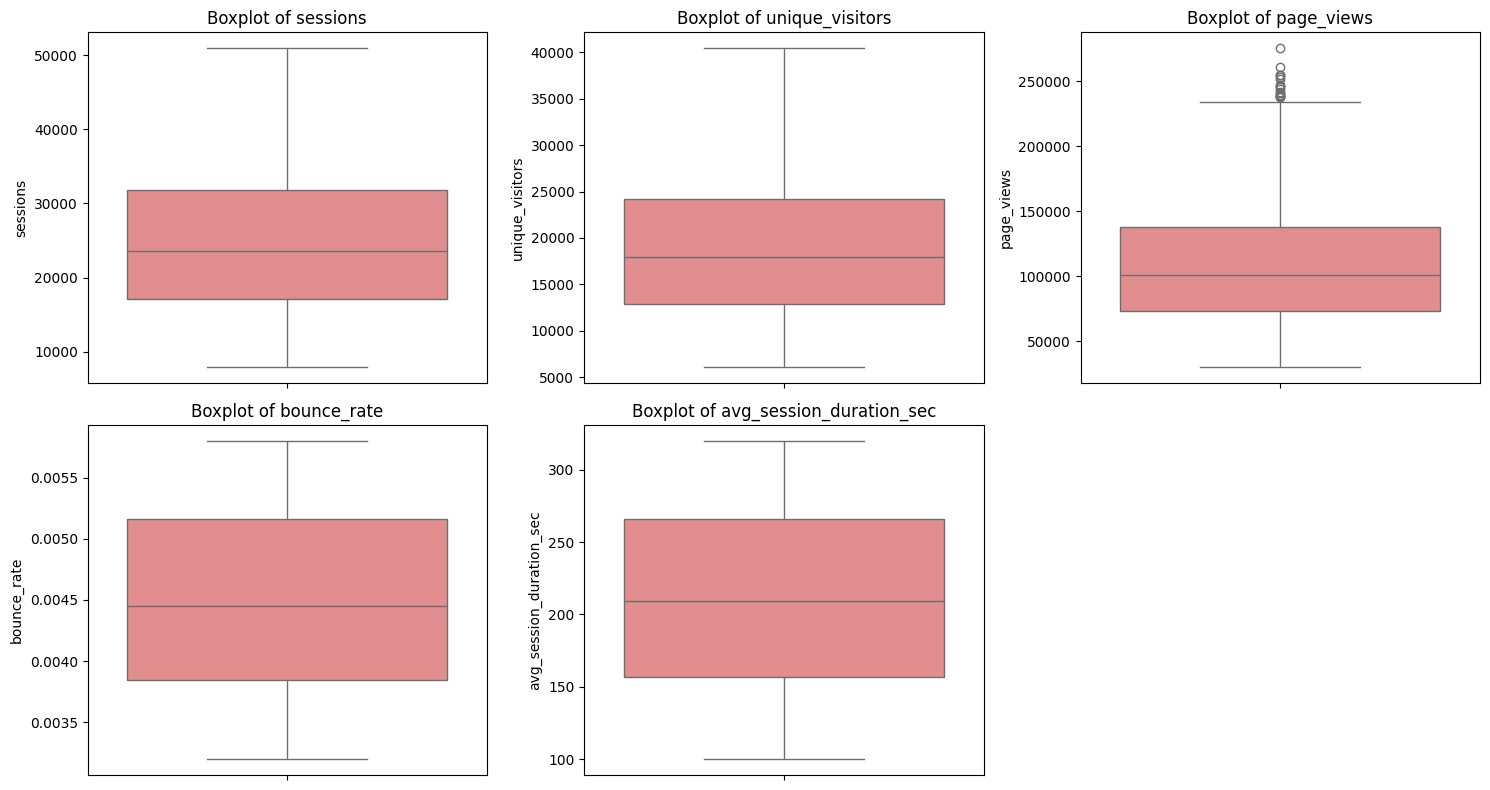

In [7]:
# Danh sách các cột dạng số
num_cols = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']

# Tính toán số lượng outliers bằng IQR
print('--- Outlier Detection (IQR) ---')
for col in num_cols:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_copy[(df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outliers')

# Trực quan hóa bằng Boxplot
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_copy[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Nhận xét về Outliers:**

- **Page Views (18 outliers):** Đây là cột duy nhất có giá trị ngoại lệ theo phương pháp IQR. Các điểm này nằm phía trên ranh giới trên (upper bound), cho thấy có những ngày lượng xem trang tăng đột biến so với bình thường. Điều này có thể do các sự kiện đặc biệt hoặc chiến dịch marketing thành công.
- **Các cột còn lại (`sessions`, `unique_visitors`, `bounce_rate`, `avg_session_duration_sec`):** Không phát hiện outlier. Điều này cho thấy dữ liệu của các chỉ số này khá ổn định và tập trung xung quanh giá trị trung tâm.
- **Kết luận:** Dữ liệu nhìn chung khá sạch. Với 18 dòng outlier trên tổng số 3,652 dòng (khoảng 0.5%), giữ lại để phân tích vì chúng phản ánh thực tế biến động của traffic website.

**Correlation Analysis**

Kiểm tra mối liên hệ giữa các biến số.

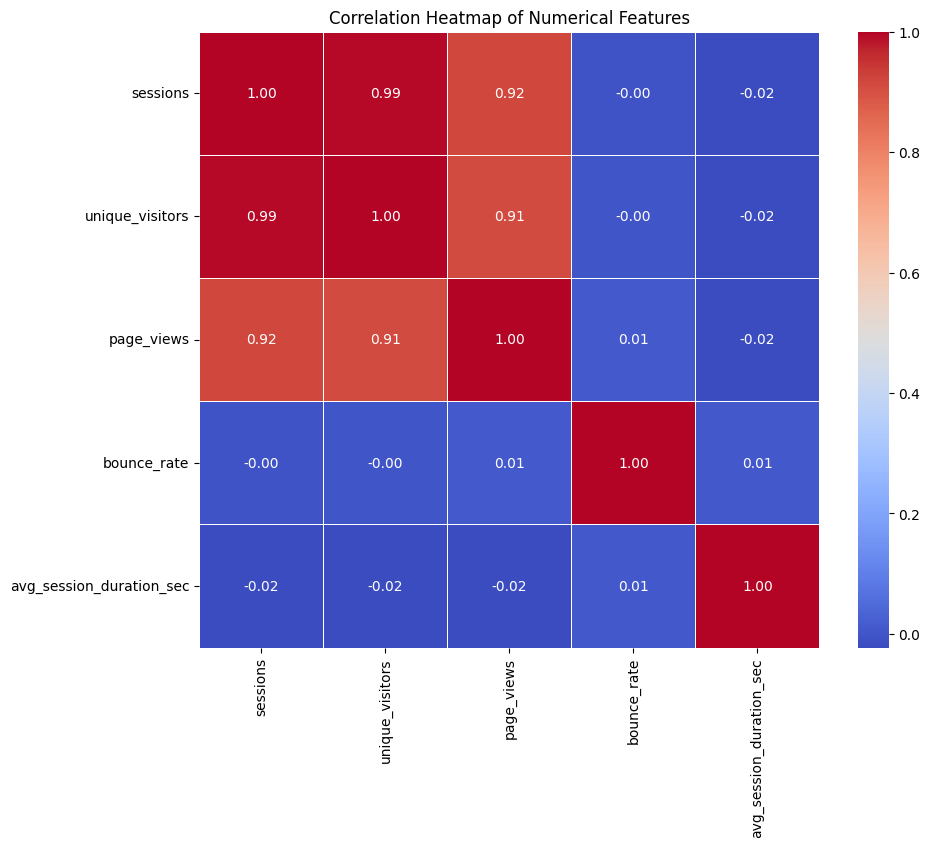

In [8]:
# Tính toán ma trận tương quan
correlation_matrix = df_copy[num_cols].corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Nhận xét về ma trận tương quan:**

1. **Tương quan cực kỳ mạnh (Strong Positive Correlation):**
    - **`sessions` và `unique_visitors` (0.99):** Gần như tương quan tuyệt đối. Điều này cho thấy đa số người dùng truy cập trang web là người dùng mới hoặc mỗi người dùng chỉ tạo ra một phiên truy cập duy nhất trong ngày.
    - **`sessions` và `page_views` (0.92):** Khi số lượng phiên truy cập tăng, tổng số lượt xem trang cũng tăng mạnh. Điều này rất hợp lý vì nhiều phiên truy cập hơn thường dẫn đến nhiều lượt xem trang hơn.

2. **Tương quan yếu hoặc không đáng kể:**
    - **`bounce_rate`:** Hầu như không có mối liên hệ tuyến tính nào với các chỉ số còn lại (các hệ số đều gần bằng 0). Điều này có nghĩa là quy mô traffic (nhiều hay ít) không ảnh hưởng đến việc người dùng có thoát trang ngay lập tức hay không.
    - **`avg_session_duration_sec`:** Cũng cho thấy sự độc lập khá cao so với các chỉ số khác. Thời gian ở lại trang của người dùng không nhất thiết tăng lên khi lượng traffic tăng.

3. **Kết luận:**
    - Các chỉ số về quy mô (`sessions`, `visitors`, `views`) đồng hành cùng nhau rất chặt chẽ.
    - Các chỉ số về hành vi (`bounce_rate`, `duration`) hoạt động độc lập và cần các chiến lược tối ưu hóa nội dung riêng biệt.

**Time Series Analysis**

Phần này tập trung vào việc tìm hiểu biến động của traffic theo thời gian, bao gồm xu hướng dài hạn (Trend) và tính chu kỳ/mùa vụ (Seasonality).

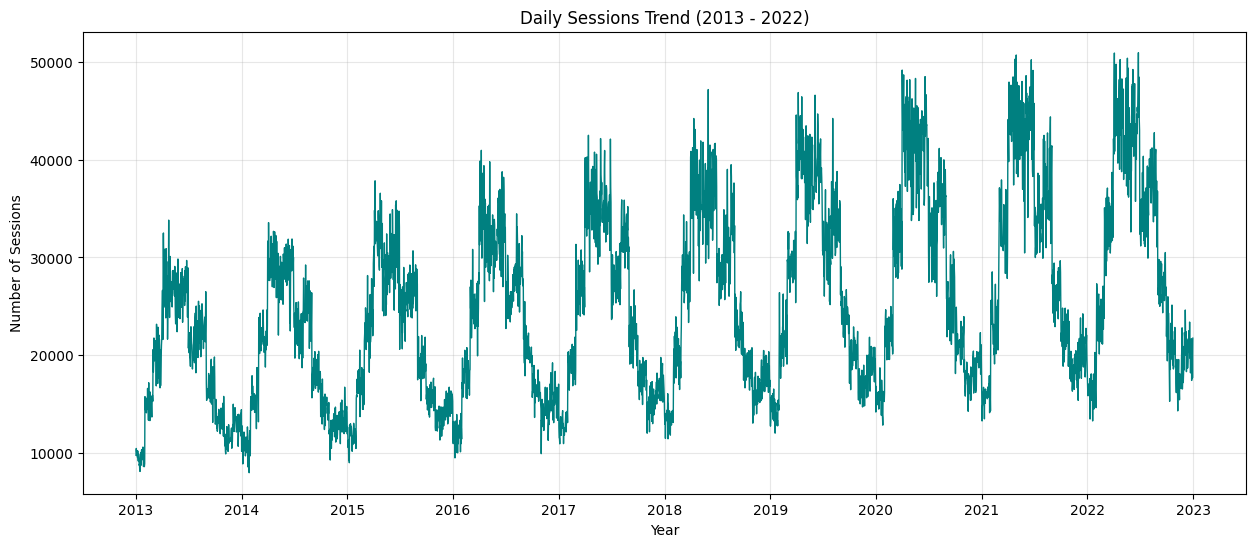

In [9]:
import matplotlib.dates as mdates

# 1. Biểu đồ xu hướng tổng thể (Daily Sessions)
plt.figure(figsize=(15, 6))
sns.lineplot(x='date', y='sessions', data=df_copy, color='teal', linewidth=1)
plt.title('Daily Sessions Trend (2013 - 2022)')
plt.xlabel('Year')
plt.ylabel('Number of Sessions')
plt.grid(True, alpha=0.3)
plt.show()

**Seasonality Analysis**

Chúng ta sẽ bóc tách dữ liệu theo Tháng và Thứ trong tuần để xem traffic thường cao nhất vào khi nào.

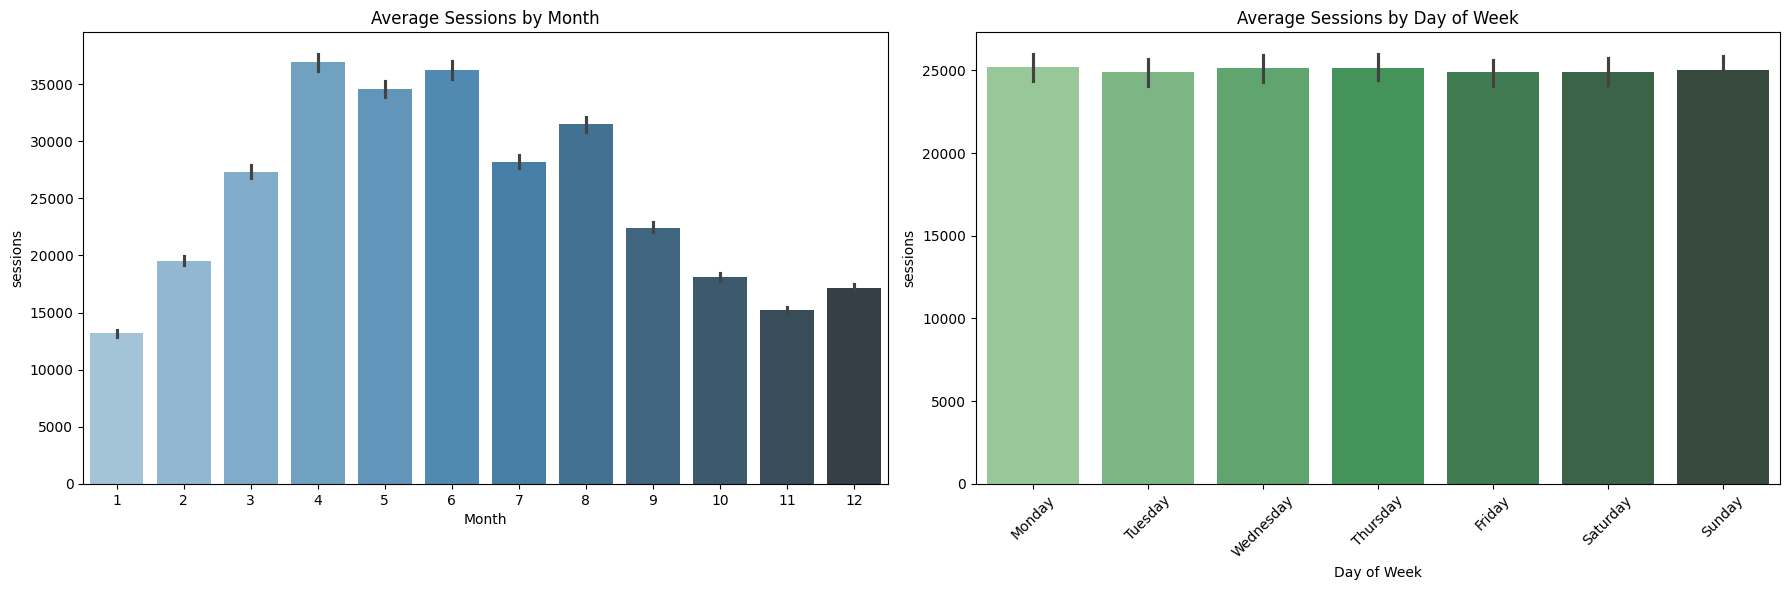

In [10]:
# Trích xuất thêm các thuộc tính thời gian
df_copy['month'] = df_copy['date'].dt.month
df_copy['day_of_week'] = df_copy['date'].dt.dayofweek
df_copy['day_name'] = df_copy['date'].dt.day_name()

# Sắp xếp thứ tự các ngày trong tuần
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Phân tích theo tháng
sns.barplot(x='month', y='sessions', data=df_copy, ax=ax[0], palette='Blues_d')
ax[0].set_title('Average Sessions by Month')
ax[0].set_xlabel('Month')

# Phân tích theo ngày trong tuần
sns.barplot(x='day_name', y='sessions', data=df_copy, ax=ax[1], order=day_order, palette='Greens_d')
ax[1].set_title('Average Sessions by Day of Week')
ax[1].set_xlabel('Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Nhận xét về Phân tích Chuỗi thời gian:**

**1. Xu hướng tổng thể (2013 - 2022):**
* Biểu đồ lưu lượng truy cập (`sessions`) cho thấy sự **tăng trưởng đều đặn và bền vững** trong suốt 10 năm qua.
* Lượng truy cập tăng từ mức trung bình khoảng 18.600 sessions/ngày (năm 2013) lên tới hơn 30.000 sessions/ngày (năm 2022).
* **Đánh giá:** Website đang phát triển rất tích cực, duy trì được đà tăng trưởng tốt và liên tục thu hút thêm người dùng mới theo thời gian.

**2. Tính mùa vụ theo Tháng (Monthly Seasonality):**
* Lưu lượng truy cập có sự **biến động rất mạnh** giữa các tháng trong năm.
* **Đỉnh điểm (Peak season):** Rơi vào Quý 2 và mùa hè (Tháng 4, 5, 6), ghi nhận mức truy cập cao nhất, có thể vượt qua 36.000 sessions/ngày.
* **Vùng thấp điểm (Off-season):** Rơi vào mùa Đông và dịp đầu năm/cuối năm (Tháng 1, 11, 12), lượng truy cập giảm sâu chỉ còn khoảng 13.000 - 15.000 sessions/ngày.
* **Đánh giá:** Website mang tính mùa vụ rất rõ rệt theo chu kỳ năm. Nội dung hoặc dịch vụ của website có thể liên quan đến các hoạt động diễn ra mạnh vào giữa năm (ví dụ: du lịch, tuyển sinh, kỳ nghỉ...).

**3. Tính mùa vụ theo Thứ trong tuần (Weekly Seasonality):**
* Trái ngược với sự biến động theo tháng, lưu lượng truy cập giữa các ngày trong tuần lại **cực kỳ đồng đều và ổn định**.
* Hoàn toàn không có sự chênh lệch giữa các ngày làm việc (Thứ 2 - Thứ 6) và ngày nghỉ (Thứ 7 - Chủ Nhật). Trung bình mỗi ngày đều đặn duy trì ở mức khoảng 25.000 sessions.
* **Đánh giá:** Nhu cầu truy cập của người dùng diễn ra mỗi ngày với tần suất không đổi, không bị phụ thuộc vào việc họ đang đi làm hay nghỉ ngơi cuối tuần.

**4. Tổng kết & Đề xuất chiến lược:**
* **Tổng kết:** Mô hình dữ liệu của website hội tụ đủ 3 yếu tố: Tăng trưởng tốt theo năm, có tính mùa vụ cao theo tháng (tập trung giữa năm) và cực kỳ ổn định theo ngày trong tuần.
* **Đề xuất chiến lược:** * Dồn trọng tâm ngân sách marketing và các chiến dịch tung sản phẩm/nội dung mới vào giai đoạn "mùa vàng" từ Tháng 4 đến Tháng 8 để tối đa hóa hiệu ứng.
  * Trong phạm vi một tuần, chiến lược phân phối nội dung và quảng cáo nên được **dàn trải đều cả 7 ngày** (không cần thiết phải phân bổ chênh lệch ngân sách giữa ngày thường và cuối tuần).
  * Về mặt kỹ thuật, cần tối ưu hóa hạ tầng máy chủ (server) vào Quý 2 để đảm bảo website không bị nghẽn mạng khi traffic tăng vọt đột biến.

### **CATEGORICAL DATA**

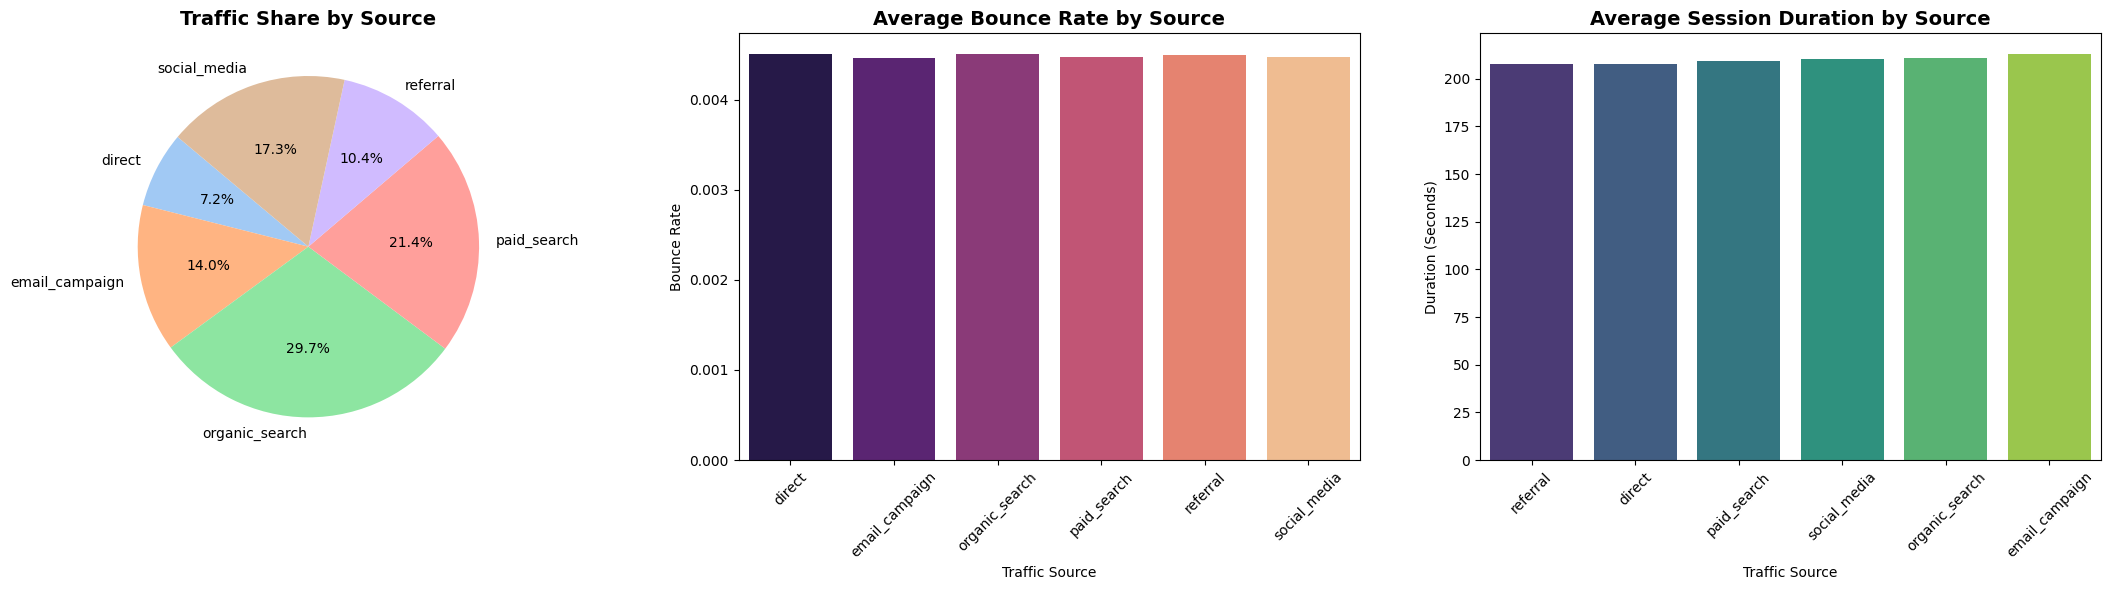

,traffic_source,total_sessions,avg_bounce_rate,avg_duration,session_percentage
2,organic_search,27196976,0.004504,211.153945,29.738897
3,paid_search,19598271,0.004478,209.362117,21.429992
5,social_media,15816226,0.004476,210.290190,17.294464
1,email_campaign,12792670,0.004458,213.220594,13.988316
4,referral,9476845,0.004499,207.558667,10.362583
0,direct,6571549,0.004511,207.678195,7.185748


In [13]:
# 1. Thống kê số lượng sessions theo nguồn
traffic_summary = df_copy.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean')
).reset_index()

# Tính tỷ lệ % đóng góp
traffic_summary['session_percentage'] = (traffic_summary['total_sessions'] / traffic_summary['total_sessions'].sum()) * 100

# 2. Trực quan hóa (Gộp 3 biểu đồ vào 1 Figure)
fig, ax = plt.subplots(1, 3, figsize=(22, 6)) # Tạo layout 1 hàng, 3 cột

# Biểu đồ 1 (Cột trái): Tỷ lệ sessions
ax[0].pie(traffic_summary['total_sessions'], labels=traffic_summary['traffic_source'], autopct='%1.1f%%',
          startangle=140, colors=sns.color_palette('pastel'))
ax[0].set_title('Traffic Share by Source', fontsize=14, fontweight='bold')

# Biểu đồ 2 (Cột giữa): So sánh Bounce Rate giữa các nguồn
sns.barplot(x='traffic_source', y='avg_bounce_rate', data=traffic_summary, ax=ax[1], palette='magma')
ax[1].set_title('Average Bounce Rate by Source', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Bounce Rate')
ax[1].set_xlabel('Traffic Source')
ax[1].tick_params(axis='x', rotation=45) # Xoay nhãn trục X 45 độ cho dễ đọc

# Biểu đồ 3 (Cột phải): So sánh thời lượng phiên trung bình
sns.barplot(x='traffic_source', y='avg_duration', data=traffic_summary.sort_values('avg_duration'), ax=ax[2], palette='viridis')
ax[2].set_title('Average Session Duration by Source', fontsize=14, fontweight='bold')
ax[2].set_xlabel('Traffic Source')
ax[2].set_ylabel('Duration (Seconds)')
ax[2].tick_params(axis='x', rotation=45) # Xoay nhãn trục X 45 độ

plt.tight_layout()
plt.show()

# 3. Hiển thị bảng dữ liệu (để xem chi tiết con số)
display(traffic_summary.sort_values(by='total_sessions', ascending=False))

**Nhận xét về Nguồn Truy cập (Traffic Sources):**

**1. Tỷ trọng các nguồn truy cập (Traffic Share):**
* **Tìm kiếm tự nhiên (Organic Search)** là kênh mang lại nhiều traffic nhất, đóng góp gần **30%** tổng lượng truy cập. Điều này cho thấy website có chiến lược SEO (Tối ưu hóa công cụ tìm kiếm) rất tốt và đang tiếp cận đúng tệp người dùng.
* Đứng thứ hai là **Paid Search** (Quảng cáo trả phí) chiếm **21.4%**. Có thể thấy website kết hợp rất nhịp nhàng giữa cả traffic tự nhiên và traffic dùng ngân sách quảng cáo.
* Kênh **Direct** (Truy cập trực tiếp) chiếm tỷ trọng thấp nhất (chỉ **7.2%**). Điều này cho thấy người dùng hiếm khi chủ động gõ trực tiếp tên miền vào trình duyệt để vào web.

**2. Tỷ lệ thoát (Average Bounce Rate):**
* Điểm đặc biệt là tỷ lệ thoát giữa tất cả các nguồn truy cập **cực kỳ đồng đều** (dao động rất hẹp quanh mức 0.0044 - 0.0045).
* **Đánh giá:** Trải nghiệm trang đích (Landing Page) được tối ưu hóa đồng bộ rất tốt. Dù người dùng đến từ bài post Facebook (Social Media), click từ quảng cáo (Paid Search) hay từ Email, họ đều có trải nghiệm nhất quán và tỷ lệ thoát trang gần như tương đương nhau.

**3. Thời lượng phiên trung bình (Average Session Duration):**
* Giống như Bounce Rate, thời gian người dùng ở lại trang giữa các kênh rất đồng đều, trung bình dao động từ **207 đến 213 giây** (khoảng 3.5 phút/phiên). Đây là một thời lượng khá ấn tượng.

**4. Tổng kết & Đề xuất chiến lược:**
* **Bảo vệ "mỏ vàng" SEO:** Tiếp tục đầu tư nội dung chất lượng cao để duy trì vị thế của Organic Search. Đây là nguồn traffic bền vững và mang lại sự gắn kết tốt.
* **Tối ưu hóa phễu Email:** Vì Email mang lại thời gian tương tác cao nhất (thời gian on-site lâu), hãy thiết kế thêm các pop-up hoặc form thu thập email người dùng trên web để mở rộng tệp khách hàng tiềm năng này.
* **Xây dựng nhận diện thương hiệu:** Tỷ lệ Direct traffic khá thấp chứng tỏ "Brand Awareness" chưa cao. Đội ngũ Marketing cần tạo ra những chiến dịch hoặc nội dung mang tính "độc quyền" để kích thích người dùng nhớ tên thương hiệu và chủ động gõ URL truy cập trực tiếp trong tương lai.

In [14]:
# Lưu file vào thư mục trên Google Drive
drive_output_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/web_traffic_cleaned.csv'
df_copy.to_csv(drive_output_path, index=False)

print(f"Đã lưu file vào Drive thành công: {drive_output_path}")

Đã lưu file vào Drive thành công: /content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/web_traffic_cleaned.csv
